In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
DATASET_PATH = r"D:\PestDetectionProject\dataset\archive (2)\InsectSound1000"

print("Dataset Path:")
print(DATASET_PATH)

Dataset Path:
D:\PestDetectionProject\dataset\archive (2)\InsectSound1000


In [3]:
import os

DATASET_PATH = r"D:\PestDetectionProject\dataset\archive (2)\InsectSound1000"

all_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            all_files.append(os.path.join(root, file))

print("Total Files Found:", len(all_files))

Total Files Found: 165981


In [4]:
selected_classes = [
    "Aphidoletes_aphidimyza",
    "Bradysia_difformis",
    "Myzus_persicae"
]

filtered_files = []

for file_path in all_files:

    filename = os.path.basename(file_path)

    parts = filename.split("_")

    if len(parts) >= 3:

        label = parts[1] + "_" + parts[2]

        if label in selected_classes:
            filtered_files.append(file_path)

print("Total Files:", len(filtered_files))

Total Files: 28666


In [5]:
from tqdm import tqdm
import librosa
import numpy as np

X = []
y = []

for file_path in tqdm(filtered_files):

    try:

        filename = os.path.basename(file_path)

        parts = filename.split("_")

        label = parts[1] + "_" + parts[2]

        audio, sr = librosa.load(
            file_path,
            sr=22050,
            duration=3
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=80
        )

        mfcc = np.mean(mfcc.T, axis=0)

        X.append(mfcc)
        y.append(label)

    except:
        pass

100%|████████████████████████████████████████████████████████████████████████████| 28666/28666 [31:54<00:00, 14.97it/s]


In [6]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

X = np.array(X)
y = np.array(y)

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes:")
print(le.classes_)

print("Total Classes:", len(le.classes_))

Classes:
['Aphidoletes_aphidimyza' 'Bradysia_difformis' 'Myzus_persicae']
Total Classes: 3


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(28666, 80, 1)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(22932, 80, 1)
(5734, 80, 1)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    Conv1D(
        128,
        kernel_size=3,
        activation='relu',
        input_shape=(80,1)
    )
)

model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(
    Conv1D(
        256,
        kernel_size=3,
        activation='relu'
    )
)

model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(LSTM(128))

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 78, 128)             │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 39, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 39, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 37, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 18, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 18, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 313,091 (1.19 MB)

 Trainable params: 313,091 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 60s 72ms/step - accuracy: 0.8852 - loss: 0.2990 - val_accuracy: 0.9255 - val_loss: 0.1934
Epoch 2/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.9367 - loss: 0.1704 - val_accuracy: 0.9386 - val_loss: 0.1574
Epoch 4/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 61s 85ms/step - accuracy: 0.9396 - loss: 0.1600 - val_accuracy: 0.9388 - val_loss: 0.1559
Epoch 5/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.9437 - loss: 0.1504 - val_accuracy: 0.9465 - val_loss: 0.1491
Epoch 6/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9464 - loss: 0.1432 - val_accuracy: 0.9343 - val_loss: 0.1741
Epoch 7/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9464 - loss: 0.1390 - val_accuracy: 0.9423 - val_loss: 0.1600
Epoch 8/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9470 - loss: 0.1358 - val_accuracy: 0.9456 - val_loss: 0.1444
Epoch 9/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.9517 - loss: 0.1291 - 

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# Model predictions
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", acc)

180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
[[2735   24   54]
 [  15 2230   34]
 [  84   41  517]]
Test Accuracy: 0.9560516219044297


In [13]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2813
           1       0.97      0.98      0.98      2279
           2       0.85      0.81      0.83       642

    accuracy                           0.96      5734
   macro avg       0.93      0.92      0.92      5734
weighted avg       0.96      0.96      0.96      5734



In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# True labels
y_true = y_test

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
Test Accuracy: 0.9560516219044297
[[2735   24   54]
 [  15 2230   34]
 [  84   41  517]]


In [16]:
print(y_test.shape)
print(type(y_test))

(5734,)
<class 'numpy.ndarray'>


In [17]:
model.save("insect_cnn_lstm_3class.h5")

180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
[[2735   24   54]
 [  15 2230   34]
 [  84   41  517]]


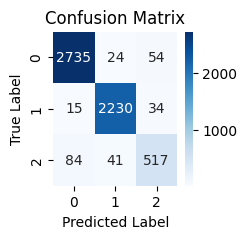

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2813
           1       0.97      0.98      0.98      2279
           2       0.85      0.81      0.83       642

    accuracy                           0.96      5734
   macro avg       0.93      0.92      0.92      5734
weighted avg       0.96      0.96      0.96      5734



In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels (already in integer form)
y_true = y_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# Plot
plt.figure(figsize=(2,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Report
print(classification_report(y_true, y_pred_classes))

In [19]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [21]:
X_flat = X.reshape(X.shape[0], X.shape[1])

print(X_flat.shape)

(28666, 80)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 78, 128)             │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 39, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 39, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 37, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 18, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 18, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 939,275 (3.58 MB)

 Trainable params: 313,091 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 626,184 (2.39 MB)

In [23]:
from sklearn.model_selection import train_test_split

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_flat,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [24]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = y_test  # only if not one-hot

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_true, y_pred_classes))

180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step
[[2735   24   54]
 [  15 2230   34]
 [  84   41  517]]


In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf')

svm.fit(X_train_ml, y_train_ml)

svm_pred = svm.predict(X_test_ml)

svm_acc = accuracy_score(y_test_ml, svm_pred)

print("SVM Accuracy:", svm_acc * 100)

SVM Accuracy: 95.76212068364144


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_ml, y_train_ml)

rf_pred = rf.predict(X_test_ml)

rf_acc = accuracy_score(y_test_ml, rf_pred)

print("Random Forest Accuracy:", rf_acc * 100)

Random Forest Accuracy: 95.09940704569236


In [27]:
X_train_svm = X_train.reshape(X_train.shape[0], -1)
X_test_svm  = X_test.reshape(X_test.shape[0], -1)

In [28]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(kf)

KFold(n_splits=5, random_state=42, shuffle=True)


In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()

svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9576212068364144


In [30]:
# Convert to 2D
X_train_svm = X_train.reshape(X_train.shape[0], -1)
X_test_svm  = X_test.reshape(X_test.shape[0], -1)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()
svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9576212068364144


In [31]:
X_train_svm = X_train.reshape(X_train.shape[0], -1)
X_test_svm  = X_test.reshape(X_test.shape[0], -1)

svm_model = SVC()
svm_model.fit(X_train_svm, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [32]:
y_pred_svm = svm_model.predict(X_test_svm)

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train_svm, y_train)   # SAME flattened data

y_pred_rf = rf_model.predict(X_test_svm)

In [34]:
print(X_train.shape)
print(X_train_svm.shape)
print(y_pred_svm[:10])

(22932, 80, 1)
(22932, 80)
[1 1 1 0 1 0 1 0 0 1]


In [35]:
print(X_train.shape)
print(X_test.shape)

(22932, 80, 1)
(5734, 80, 1)


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Flatten, Input

model = Sequential([
    Input(shape=(80, 1)),   # ✅ FIXED HERE
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [37]:
model.fit(X_train, y_train,
          epochs=20,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 100s 117ms/step - accuracy: 0.8782 - loss: 0.3278 - val_accuracy: 0.9213 - val_loss: 0.2150
Epoch 2/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 86s 120ms/step - accuracy: 0.9268 - loss: 0.2023 - val_accuracy: 0.9295 - val_loss: 0.2021
Epoch 3/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 71s 99ms/step - accuracy: 0.9313 - loss: 0.1935 - val_accuracy: 0.9332 - val_loss: 0.1859
Epoch 4/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 74s 103ms/step - accuracy: 0.9359 - loss: 0.1792 - val_accuracy: 0.9327 - val_loss: 0.1892
Epoch 5/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 71s 98ms/step - accuracy: 0.9371 - loss: 0.1734 - val_accuracy: 0.9358 - val_loss: 0.1765
Epoch 6/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 80s 112ms/step - accuracy: 0.9376 - loss: 0.1684 - val_accuracy: 0.9374 - val_loss: 0.1841
Epoch 7/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 70s 98ms/step - accuracy: 0.9400 - loss: 0.1612 - val_accuracy: 0.9363 - val_loss: 0.1750
Epoch 8/20
717/717 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9413 - loss: 0.15

In [ ]:
!pip install scikeras

In [38]:
from scikeras.wrappers import KerasClassifier

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model():
    model = Sequential()
    
    model.add(Dense(64, activation='relu', input_shape=(X.shape[1],)))
    model.add(Dense(32, activation='relu'))
    
    # change this based on your classes:
    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [40]:
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(
    model=build_model,
    epochs=20,
    batch_size=32,
    verbose=0
)

In [41]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [42]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app', 'dataset', 'insect_cnn_lstm_3class.h5', 'models', 'notebooks', 'outputs', 'pest_detection.ipynb', 'temp.wav', 'X.npy', 'X_features.npy', 'y.npy', 'y_labels.npy']


In [43]:
import numpy as np

X = np.load("X.npy")
y = np.load("y.npy")

In [44]:
print(X.shape)
print(y.shape)

(8000, 40)
(8000,)


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model():
    model = Sequential()
    
    model.add(Dense(64, activation='relu', input_shape=(X.shape[1],)))
    model.add(Dense(32, activation='relu'))
    
    # output layer
    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',  # IMPORTANT FIX
        metrics=['accuracy']
    )
    
    return model

In [46]:
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(
    model=build_model,
    epochs=20,
    batch_size=32,
    verbose=0
)

In [47]:
def build_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))  # 3 classes
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [48]:
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(model=build_model, epochs=20, batch_size=32, verbose=0)

In [49]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
print(scores)
print("Mean:", scores.mean())

C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

[0.853125 0.84     0.861875 0.87125  0.836875]
Mean: 0.852625


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
model.fit(X_train, y_train)

C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,model,<function bui...0022F39A7A200>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,32
,validation_batch_size,None
,verbose,0
,callbacks,None


In [52]:
y_proba = model.predict_proba(X_test)
y_true = y_test

In [53]:
%matplotlib inline

In [54]:
y_proba = model.predict_proba(X_test)
y_true = y_test

In [55]:
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2]
y_true_bin = label_binarize(y_true, classes=classes)
n_classes = y_true_bin.shape[1]

In [56]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [57]:
print(fpr.keys())
print(tpr.keys())

dict_keys([0, 1, 2])
dict_keys([0, 1, 2])


In [58]:
print(y_proba.shape)
print(y_test.shape)

(1600, 3)
(1600,)


In [59]:
print(np.unique(y_test))
print(y_test[:20])

['aphidimyza' 'difformis' 'persicae']
['aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza'
 'aphidimyza' 'aphidimyza' 'persicae' 'aphidimyza' 'aphidimyza'
 'aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza'
 'persicae' 'difformis' 'persicae' 'aphidimyza' 'aphidimyza']


In [60]:
print(type(y_test[0]))

<class 'numpy.str_'>


In [61]:
print("Unique values in y_test:")
print(np.unique(y_test))

print("\nFirst 20 labels:")
print(y_test[:20])

Unique values in y_test:
['aphidimyza' 'difformis' 'persicae']

First 20 labels:
['aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza'
 'aphidimyza' 'aphidimyza' 'persicae' 'aphidimyza' 'aphidimyza'
 'aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza' 'aphidimyza'
 'persicae' 'difformis' 'persicae' 'aphidimyza' 'aphidimyza']


In [62]:
for x in np.unique(y_test):
    print(repr(x))

'aphidimyza'
'difformis'
'persicae'


In [63]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=[
        'aphidimyza',
        'difformis',
        'persicae'
    ]
)

print(y_test_bin.shape)
print(y_test_bin[:5])

(1600, 3)
[[1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]


In [64]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_proba[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

for i in range(3):
    print(f"Class {i} AUC = {roc_auc[i]:.4f}")

Class 0 AUC = 0.9654
Class 1 AUC = 0.9946
Class 2 AUC = 0.9389


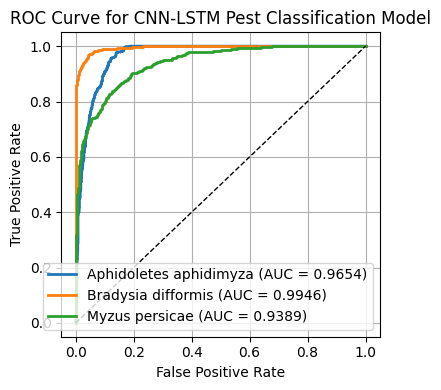

In [65]:
import matplotlib.pyplot as plt

class_names = [
    "Aphidoletes aphidimyza",
    "Bradysia difformis",
    "Myzus persicae"
]

plt.figure(figsize=(4,4))

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for CNN-LSTM Pest Classification Model")
plt.legend(loc="lower right")

plt.grid(True)
plt.tight_layout()

plt.show()

In [66]:
import numpy as np

print(np.unique(y_test, return_counts=True))

(array(['aphidimyza', 'difformis', 'persicae'], dtype='<U10'), array([570, 543, 487], dtype=int64))


In [67]:
from sklearn.preprocessing import label_binarize

classes = ['aphidimyza', 'difformis', 'persicae']

y_test_bin = label_binarize(y_test, classes=classes)

In [68]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, test_idx in kf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    scores.append(acc)

print("Fold Accuracies:", scores)
print("Mean:", np.mean(scores))
print("Std:", np.std(scores))

C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\sri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

Fold Accuracies: [0.863125, 0.803125, 0.810625, 0.72125, 0.845625]
Mean: 0.8087500000000001
Std: 0.04900573945978167


In [ ]:
y_pred = model.predict(X_test)

print(y_pred.shape)
print(y_pred[:10])

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['aphidimyza', 'difformis', 'persicae']
)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Aphidimyza', 'Actual Difformis', 'Actual Persicae'],
    columns=['Pred Aphidimyza', 'Pred Difformis', 'Pred Persicae']
)

print(cm_df)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['aphidimyza', 'difformis', 'persicae']
)

plt.figure(figsize=(4,2))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Aphidoletes aphidimyza',
        'Bradysia difformis',
        'Myzus persicae'
    ],
    yticklabels=[
        'Aphidoletes aphidimyza',
        'Bradysia difformis',
        'Myzus persicae'
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix of Proposed CNN-LSTM Model")

plt.show()

In [ ]:
print(cm)